# Fitting and evaluating the ranker — all features accepted

Start here **after feature selection**. Every supplied feature is accepted unchanged.
This notebook runs independently: you do not need to run or import another notebook.

**Prepared features + completed outcome scores → time splits → grades + query groups
→ fit one trial → tune → refit → evaluate on 2021.**

We keep the four trend columns, 14 indices plus learned SKIP, and the model settings from
the [lighter cycle notebook](harvesting_vrp_trend_walkthrough.ipynb). There is no S1–S5,
VIX, interaction construction, or strategy-history calculation here. The outcome score `z`
is assumed prepared upstream; our small generator fabricates it directly.

The focus is **ranking quality**, measured on untouched 2021 outcomes. Model scores are
not probabilities or forecasts of dollars. Gate calibration, risk-unit sizing and portfolio
returns are separate downstream steps in the cycle notebook; NDCG alone does not establish
a profitable strategy.

Source: [paper, model configuration and search](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md#lightgbm-configuration-and-search-source-table-1).
Use the project's DEV Python environment. All outputs below are synthetic teaching results.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from IPython.display import display

SEED = 260824786  # Same reproducible synthetic seed as the companion notebooks.
TRIALS, ROUNDS, PATIENCE = 50, 2000, 50  # Paper settings, not reduced demo budgets.
GAINS = np.array([0, 1, 3, 7, 15])
TICKERS = ['SPX', 'NDX', 'RUT', 'SX5E', 'DAX', 'CAC', 'FTSE',
           'SMI', 'IBEX', 'AEX', 'N225', 'HSI', 'AS51', 'TSX']
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Small prepared-input example

The generator below is data setup, not model fitting. It computes four familiar trend
descriptors from fake prices, then shifts them once: an EOD t decision uses EOD t−1 features.
These candidate-specific (PS) columns are **assumed to have survived selection**, regardless
of what a screen would decide on this fabricated sample. Warm-up values remain missing.

For the demonstration, future `z` depends on lagged trend plus noise. In real data it is
the completed trade's gross downside-adjusted score from the
[P&L-shaping step](harvesting_vrp_pnl_shaping.ipynb). We do not reinterpret these fake `z`
values as option P&L. Coefficients in the generator describe invented data, not model settings.

The availability clock retains your 10-business-day-or-expiry exit and the M1 <5-day
entry roll. The toy calendar uses weekdays and third-Friday expiries. A real prepared
table must carry actual completion timestamps and historical market calendars.

In [2]:
def synthetic_inputs():
    rng = np.random.default_rng(SEED)
    dates = pd.bdate_range('2013-01-01', '2021-12-31')
    prices = pd.DataFrame(100 * np.exp(rng.normal(0, .01, (len(dates), len(TICKERS))).cumsum(axis=0)),
                          index=dates, columns=TICKERS)
    ma50, ma200 = prices.rolling(50).mean(), prices.rolling(200).mean()
    raw = {'distance_50': prices / ma50 - 1, 'distance_200': prices / ma200 - 1,
           'cross_50_200': np.sign(ma50 - ma200), 'slope_200_21': ma200 / ma200.shift(21) - 1}
    features = pd.DataFrame({name: value.shift(1).stack(future_stack=True)
                             for name, value in raw.items()}).rename_axis(['date', 'candidate'])
    entry = features.index.get_level_values('date')
    expiries = pd.date_range('2013-01-01', '2022-02-28', freq='WOM-3FRI').to_numpy()
    front = np.searchsorted(expiries, entry.to_numpy())
    remaining = np.busday_count(entry.to_numpy().astype('datetime64[D]'),
                               expiries[front].astype('datetime64[D]'))
    expiry = expiries[front + (remaining < 5)]
    exit_date = np.minimum((entry + pd.offsets.BDay(10)).to_numpy(), expiry)
    outcomes = pd.DataFrame(index=features.index)
    outcomes['observed_at'] = entry - pd.offsets.BDay(1)
    outcomes['label_available'] = exit_date
    outcomes['z'] = (.5 + 2 * np.tanh(features.distance_50.fillna(0) / .05)
                     + rng.normal(0, 1, len(features)))
    skip = pd.DataFrame(index=pd.MultiIndex.from_product([dates, ['SKIP']], names=features.index.names))
    skip['observed_at'] = dates - pd.offsets.BDay(1)
    skip['label_available'] = outcomes.label_available.groupby(level='date').max().reindex(dates).to_numpy()
    skip['z'] = 0.
    outcomes = pd.concat([outcomes, skip]).sort_index()
    return features.reindex(outcomes.index), outcomes

### THE DATA BOUNDARY — change only this cell to use prepared real data

Leave `INPUT_DIRECTORY = None` to run the synthetic example. Set it to your directory
containing **`features.parquet`** and **`outcomes.parquet`** to use prepared data instead.
Save these with their pandas MultiIndex preserved, for example `X.to_parquet(...)`.

| Object | Contract |
|---|---|
| `X` | Numeric feature columns only; `(date, candidate)` index; sorted; values already aligned to t−1; NaNs allowed |
| `outcomes` | Same index; continuous completed `z`, `observed_at`, and `label_available` timestamps |
| Each date | All 14 real candidates plus SKIP; do not infer the entry universe from completed trades only |
| SKIP | `z = 0`; ordinary PS feature values missing; shared CS context, if supplied, copied normally |

`observed_at` means the latest information used by the row, including its publication time.
The labels are future outcomes and belong only in training/evaluation, never in `X`.
Raw Qbit preparation and unit normalization remain upstream in [v2](harvesting_vrp_synthetic_v2.ipynb).
This example's one-cycle date boundaries are explicit in the next section.

In [3]:
INPUT_DIRECTORY = None  # Or Path('/your/prepared/model_inputs').
if INPUT_DIRECTORY is None:
    X, outcomes = synthetic_inputs()
else:
    X = pd.read_parquet(Path(INPUT_DIRECTORY) / 'features.parquet')
    outcomes = pd.read_parquet(Path(INPUT_DIRECTORY) / 'outcomes.parquet')

assert X.index.names == ['date', 'candidate'] and X.index.equals(outcomes.index)
assert X.index.is_unique and X.index.is_monotonic_increasing and X.columns.is_unique
assert len(X.columns) > 0 and all(pd.api.types.is_numeric_dtype(dtype) for dtype in X.dtypes)
assert not np.isinf(X.to_numpy()).any() and not np.isinf(outcomes.z.to_numpy()).any()
row_dates = X.index.get_level_values('date')
candidate_names = X.index.get_level_values('candidate')
real = candidate_names != 'SKIP'
assert (outcomes.observed_at < row_dates).all()
assert (outcomes.label_available.dropna() >= row_dates[outcomes.label_available.notna()]).all()
assert outcomes.loc[~real, 'z'].eq(0).all()
expected_candidates = set(TICKERS) | {'SKIP'}
assert all(set(group.index.get_level_values('candidate')) == expected_candidates
           for _, group in X.groupby(level='date'))
features = X.columns.tolist()  # ALL supplied columns. There is no feature-selection call.
display(pd.Series({'features accepted': len(features), 'queries': row_dates.nunique(),
                   'candidates per query': len(expected_candidates)}))
print('Model columns:', features)

features accepted          4
queries                 2349
candidates per query      15
dtype: int64

Model columns: ['distance_50', 'distance_200', 'cross_50_200', 'slope_200_21']


## 2. Give each period one job

| Role | Entry dates | What it decides |
|---|---|---|
| Trial fitting | 2013–2019 | Each trial's fitted trees and grade cutpoints |
| Search validation | Jan–Jun 2020 | Which hyperparameter configuration wins |
| Early stopping | Apr–Jun 2020 | How many trees to keep |
| Final refit | 2013–Mar 2020 | Winning configuration's final fitted trees and new cutpoints |
| Gate holdout | Jul–Dec 2020 | Reserved for downstream confidence calibration; unused here |
| Test | 2021 | Evaluate the frozen model, without fitting anything |

As in the existing walkthrough, the final three-month stopping slice is contained within
the six-month search-validation slice. Their scores are therefore **not independent**.
After 50 trials, the best validation score is a selection result, not an unbiased performance
estimate. The untouched 2021 period is the evaluation period.

For fitting/validation, discard a **whole daily query** if any candidate's outcome is not
known before that period's end. This purges trades crossing a boundary, not merely rows
whose entry dates are too late. We keep 2021 entry queries for prediction and wait for their
outcomes when evaluating; year-end trades can finish in January 2022.

In [4]:
def period(start, end):
    known = outcomes.z.notna() & outcomes.label_available.lt(pd.Timestamp(end))
    whole_query_known = known.groupby(level='date').transform('all').to_numpy()
    return (row_dates >= pd.Timestamp(start)) & (row_dates < pd.Timestamp(end)) & whole_query_known


search_fit = period('2013-01-01', '2020-01-01')
validation = period('2020-01-01', '2020-07-01')
early_stop = period('2020-04-01', '2020-07-01')
refit = period('2013-01-01', '2020-04-01')
test = (row_dates >= pd.Timestamp('2021-01-01')) & (row_dates < pd.Timestamp('2022-01-01'))
masks = {'trial fit': search_fit, 'search validation': validation,
         'early stopping': early_stop, 'final refit': refit, '2021 test': test}
split_table = pd.DataFrame({name: {
    'queries': row_dates[mask].nunique(), 'first entry': row_dates[mask].min(),
    'last entry': row_dates[mask].max(),
    'last outcome available': outcomes.loc[mask, 'label_available'].max(),
} for name, mask in masks.items()}).T
assert (split_table.queries > 0).all()
display(split_table)

,queries,first entry,last entry,last outcome available
trial fit,1816,2013-01-01 00:00:00,2019-12-17 00:00:00,2019-12-31 00:00:00
search validation,120,2020-01-01 00:00:00,2020-06-16 00:00:00,2020-06-30 00:00:00
early stopping,55,2020-04-01 00:00:00,2020-06-16 00:00:00,2020-06-30 00:00:00
final refit,1881,2013-01-01 00:00:00,2020-03-17 00:00:00,2020-03-31 00:00:00
2021 test,261,2021-01-01 00:00:00,2021-12-31 00:00:00,2022-01-14 00:00:00


## 3. From continuous `z` to integer grades

LightGBM sees grades **0, 1, 2, 3, 4**. Fit the 10%, 40%, 60%, and 90% quantiles of
**real-candidate trial-fitting outcomes**, pooled across dates. Freeze those cutpoints
when grading validation/stopping outcomes. These are not daily cross-sectional ranks.

An observation equal to a cutpoint goes in the lower grade. SKIP's zero `z` goes through
the same mapping; its grade is not hard-coded. The paper reports SKIP grade 1 in its data,
which is not a requirement for this synthetic example.

| Grade | Gain used by LambdaRank and NDCG |
|---|---|
| 0 | 0 |
| 1 | 1 |
| 2 | 3 |
| 3 | 7 |
| 4 | 15 |

Keep the three quantities separate: **`z` is a realized outcome score; `grade` is a training
target; `score` will be a model prediction.** None of them becomes an extra input column.

In [5]:
def grade_cuts(mask):
    return outcomes.loc[mask & real, 'z'].quantile([.10, .40, .60, .90]).to_numpy()


def grade(values, cuts):
    return pd.Series(np.searchsorted(cuts, values.to_numpy(), side='left').astype(np.int32),
                     index=values.index, name='grade')


cuts = grade_cuts(search_fit)
display(pd.Series(cuts, index=['10%', '40%', '60%', '90%'], name='trial-fit z cutpoint'))
example_day = row_dates[validation].min()
example = X.loc[example_day].join(outcomes.loc[example_day, ['z']])
example['grade'] = grade(example.z, cuts)
example['gain'] = GAINS[example.grade]
display(example)
display(grade(outcomes.loc[search_fit & real, 'z'], cuts).value_counts(normalize=True)
        .sort_index().rename('trial-fit real-candidate grade fraction'))

10%   -1.454848
40%    0.070965
60%    0.887160
90%    2.427195
Name: trial-fit z cutpoint, dtype: float64

,distance_50,distance_200,cross_50_200,slope_200_21,z,grade,gain
candidate,,,,,,,
AEX,0.001247,-0.067861,-1.0,-0.014267,-0.880432,1,1
AS51,-0.022747,-0.091667,-1.0,-0.019144,-0.850463,1,1
CAC,-0.064341,-0.118507,-1.0,-0.018363,-0.302526,1,1
DAX,-0.068214,-0.126399,-1.0,-0.016964,-1.298480,1,1
FTSE,0.011994,0.011673,-1.0,-0.002446,2.083286,3,7
HSI,0.007405,0.016104,1.0,0.000152,0.869758,2,3
IBEX,-0.070259,-0.129786,-1.0,-0.017960,-0.676403,1,1
N225,-0.027884,0.006184,1.0,0.003968,-1.139173,1,1
NDX,0.017885,0.109114,1.0,0.014075,0.115318,2,3


grade
0    0.100024
1    0.299992
2    0.199969
3    0.299992
4    0.100024
Name: trial-fit real-candidate grade fraction, dtype: float64

## 4. A date is one ranking query

The model compares candidates **within the same entry date**, not across unrelated dates.
LightGBM needs the number of consecutive rows belonging to each date: here `group` contains
15 repeatedly (14 indices + SKIP). It is a group-size vector, not a vector of date IDs.

Rows are sorted by date and candidate. Only numeric feature values go into `lgb.Dataset`;
candidate names and dates identify queries and break prediction ties, but are not features.
LightGBM handles NaNs directly. Nothing scales or cross-ranks `X` at this step.

In [6]:
def dataset(mask, cutpoints, reference=None):
    frame = X.loc[mask, features]
    groups = frame.groupby(level='date', sort=False).size().to_numpy()
    return lgb.Dataset(frame.to_numpy(), label=grade(outcomes.loc[mask, 'z'], cutpoints).to_numpy(),
                       group=groups, feature_name=features, reference=reference,
                       params={'feature_pre_filter': False})


train_set = dataset(search_fit, cuts)
stop_set = dataset(early_stop, cuts, train_set)
groups = X.loc[search_fit].groupby(level='date', sort=False).size()
group_table = groups.rename('rows').to_frame()
group_table['first_row_offset'] = group_table.rows.cumsum() - group_table.rows
display(group_table.head())
print('Rows in fit matrix:', int(groups.sum()), '| group vector length:', len(groups))

,rows,first_row_offset
date,,
2013-01-01,15,0
2013-01-02,15,15
2013-01-03,15,30
2013-01-04,15,45
2013-01-07,15,60


Rows in fit matrix: 27240 | group vector length: 1816


## 5. What LambdaRank fits

Each tree adjusts candidate scores to improve ordering within queries. Pairs with different
grades contribute gradients weighted by the NDCG change from swapping them. Higher grades
have nonlinear gains `[0, 1, 3, 7, 15]`; errors near the top matter more.

`lambdarank_truncation_level=5` focuses LambdaRank's objective near the top five positions.
It does **not** remove the other candidates or mean we trade five positions. We monitor
NDCG@1 and NDCG@3; NDCG@1 controls early stopping and hyperparameter selection.

Each trial proposes eight settings below. The paper leaves the API names of its two
subsampling fractions ambiguous; like v2, we interpret them as column (`feature_fraction`)
and row (`bagging_fraction`) sampling. Seeds and deterministic execution are reconstruction
choices. `feature_pre_filter=False` prevents dataset creation from pre-removing a column
while `min_data_in_leaf` changes between trials. Trees can still choose not to split on it.

In [7]:
base_params = dict(objective='lambdarank', metric='ndcg', ndcg_eval_at=[1, 3],
    label_gain=GAINS.tolist(), lambdarank_truncation_level=5, verbosity=-1,
    deterministic=True, force_col_wise=True, feature_pre_filter=False,
    seed=SEED + 2021, num_threads=int(os.environ.get('OMP_NUM_THREADS', 0)))


def suggest_params(trial):
    return dict(
        num_leaves=trial.suggest_int('num_leaves', 16, 256, log=True),
        learning_rate=trial.suggest_float('learning_rate', .01, .10, log=True),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 200, log=True),
        feature_fraction=trial.suggest_float('feature_fraction', .5, 1.),
        bagging_fraction=trial.suggest_float('bagging_fraction', .5, 1.),
        bagging_freq=trial.suggest_int('bagging_freq', 0, 10),
        lambda_l1=trial.suggest_float('lambda_l1', 1e-3, 10., log=True),
        lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10., log=True))


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED + 2021))
first_trial = study.ask()  # This is trial 1 of the paper's 50, not an extra preliminary trial.
first_params = suggest_params(first_trial)
display(pd.Series(first_params, name='first trial settings'))

num_leaves          77.000000
learning_rate        0.046879
min_data_in_leaf    27.000000
feature_fraction     0.990272
bagging_fraction     0.591869
bagging_freq         9.000000
lambda_l1            0.010000
lambda_l2            0.004419
Name: first trial settings, dtype: float64

## 6. Fit the first trial, visibly

`train_set` supplies features, grades and query sizes. `stop_set` contains April–June 2020
and is used only to monitor the fit. Up to 2,000 rounds are allowed; stop after 50 rounds
without an improvement in NDCG@1. Keep the iteration with the best stopping score.

The curve contains the later rounds used to establish that improvement stopped. Predictions
below explicitly use `best_iteration`, not the last point drawn on the curve.

First trial: best iteration = 2


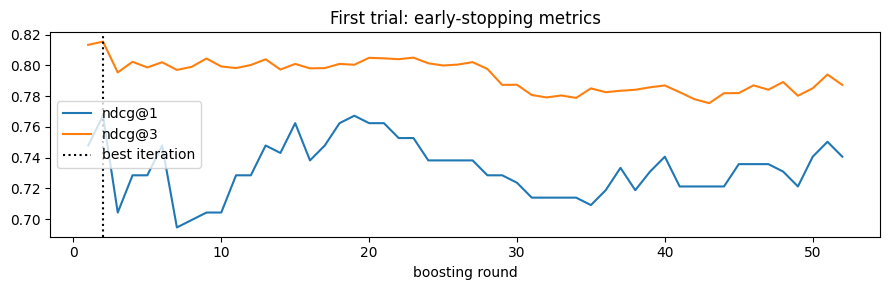

In [8]:
first_history = {}
first_model = lgb.train(dict(base_params, **first_params), train_set,
    num_boost_round=ROUNDS, valid_sets=[stop_set], valid_names=['early_stop'],
    callbacks=[lgb.early_stopping(PATIENCE, first_metric_only=True, verbose=False),
               lgb.record_evaluation(first_history)])
print('First trial: best iteration =', first_model.best_iteration)
learning_curve = pd.DataFrame(first_history['early_stop'])
learning_curve.index = pd.RangeIndex(1, len(learning_curve) + 1, name='boosting round')
ax = learning_curve.plot(figsize=(9, 3), title='First trial: early-stopping metrics')
ax.axvline(first_model.best_iteration, color='black', linestyle=':', label='best iteration')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Evaluate a ranking: NDCG by hand, then across days

Sort predictions from highest to lowest. For the candidate at position (i), its contribution is


\[
\mathrm{DCG@k}=\sum_{i=1}^{k}\frac{\mathrm{gain}(g_i)}{\log_2(i+1)},\qquad
\mathrm{NDCG@k}=\frac{\mathrm{DCG@k}}{\mathrm{ideal\ DCG@k}}.
\]

The ideal order sorts the **realized grades** from best to worst. It is used to score a
prediction retrospectively, never to make a trading decision. NDCG is between zero and one;
at @1 it is simply the chosen candidate's gain divided by that day's largest gain.

We calculate one metric per date, then average dates equally. Multiple candidates can share
the highest grade, so selecting any of them earns NDCG@1 = 1 even if their continuous `z`
values differ. A query with all zero gains receives 1, matching LightGBM's convention.
Exact prediction ties use alphabetical candidate order in our reported metrics.

In [9]:
def daily_ndcg(scores, grades):
    predicted = scores.unstack('candidate').sort_index(axis=1)
    labels = grades.unstack('candidate').reindex(index=predicted.index, columns=predicted.columns)
    gains = GAINS[labels.to_numpy(dtype=int)]
    order = np.argsort(-predicted.to_numpy(), axis=1, kind='stable')
    actual = np.take_along_axis(gains, order, axis=1)
    ideal = np.sort(gains, axis=1)[:, ::-1]
    discount = 1 / np.log2(np.arange(gains.shape[1]) + 2)
    result = {}
    for k in [1, 3]:
        dcg = (actual[:, :k] * discount[:k]).sum(axis=1)
        idcg = (ideal[:, :k] * discount[:k]).sum(axis=1)
        result[f'NDCG@{k}'] = np.divide(dcg, idcg, out=np.ones_like(dcg), where=idcg != 0)
    return pd.DataFrame(result, index=predicted.index)


validation_grades = grade(outcomes.loc[validation, 'z'], cuts)
first_scores = pd.Series(first_model.predict(X.loc[validation, features].to_numpy(),
    num_iteration=first_model.best_iteration), index=X.index[validation], name='score')
worked = first_scores.loc[example_day].to_frame().join(validation_grades.loc[example_day])
worked = worked.sort_index().sort_values('score', ascending=False, kind='stable')
worked['position'] = np.arange(1, len(worked) + 1)
worked['gain'] = GAINS[worked.grade]
worked['discount'] = 1 / np.log2(worked.position + 1)
worked['discounted_gain'] = worked.gain * worked.discount
display(worked)
first_metrics = daily_ndcg(first_scores, validation_grades)
display(first_metrics.loc[[example_day]])
display(first_metrics.mean().rename('first trial: Jan–Jun validation mean'))

,score,grade,position,gain,discount,discounted_gain
candidate,,,,,,
SMI,0.091902,1,1,1,1.000000,1.000000
SPX,0.066272,4,2,15,0.630930,9.463946
HSI,0.030422,2,3,3,0.500000,1.500000
FTSE,0.014249,3,4,7,0.430677,3.014736
NDX,-0.039974,2,5,3,0.386853,1.160558
RUT,-0.095827,1,6,1,0.356207,0.356207
AEX,-0.096481,1,7,1,0.333333,0.333333
AS51,-0.098944,1,8,1,0.315465,0.315465
SKIP,-0.118154,1,9,1,0.301030,0.301030


,NDCG@1,NDCG@3
date,,
2020-01-01,0.066667,0.571986


NDCG@1    0.795238
NDCG@3    0.836144
Name: first trial: Jan–Jun validation mean, dtype: float64

## 8. Repeat the same fit for the remaining trials

Optuna's TPE sampler proposes settings using completed trial results. Every trial uses the
same fitting data, the same frozen grade cutpoints, and the same stopping/validation dates.
Only hyperparameters and the resulting fitted trees change.

The objective returned to Optuna is **mean validation NDCG@1**. We record NDCG@3 for
inspection, but do not use it to choose the winning trial. Trial numbers start at zero.
The first fit above is registered as a completed trial; 49 more bring the total to 50.

,number,value,user_attrs_NDCG@3,user_attrs_best_iteration
16,16,0.832540,0.833192,6
26,26,0.832222,0.830546,27
21,21,0.830952,0.841327,55
48,48,0.830952,0.839240,28
43,43,0.830952,0.844224,113


num_leaves          106.000000
learning_rate         0.099451
min_data_in_leaf     59.000000
feature_fraction      0.809780
bagging_fraction      0.767698
bagging_freq          4.000000
lambda_l1             0.005082
lambda_l2             0.018782
Name: winning configuration, dtype: float64

Winning trial: 16 | validation NDCG@1: 0.8325396825396825


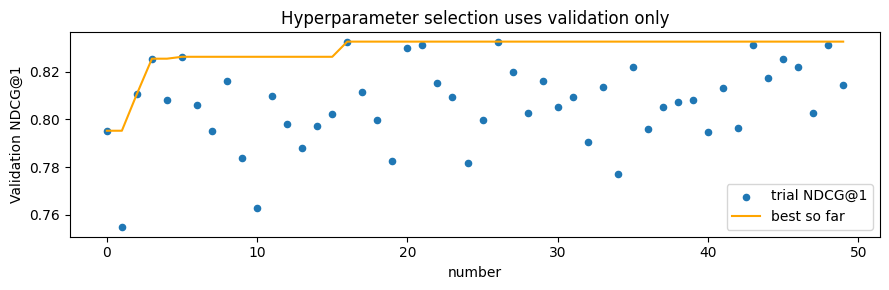

In [10]:
first_trial.set_user_attr('best_iteration', first_model.best_iteration)
first_trial.set_user_attr('NDCG@3', float(first_metrics['NDCG@3'].mean()))
study.tell(first_trial, float(first_metrics['NDCG@1'].mean()))


def objective(trial):
    params = suggest_params(trial)
    trial_model = lgb.train(dict(base_params, **params), train_set,
        num_boost_round=ROUNDS, valid_sets=[stop_set], valid_names=['early_stop'],
        callbacks=[lgb.early_stopping(PATIENCE, first_metric_only=True, verbose=False)])
    scores = pd.Series(trial_model.predict(X.loc[validation, features].to_numpy(),
        num_iteration=trial_model.best_iteration), index=X.index[validation])
    metrics = daily_ndcg(scores, validation_grades).mean()
    trial.set_user_attr('best_iteration', trial_model.best_iteration)
    trial.set_user_attr('NDCG@3', float(metrics['NDCG@3']))
    return float(metrics['NDCG@1'])


study.optimize(objective, n_trials=TRIALS - 1)
trials = study.trials_dataframe()
display(trials[['number', 'value', 'user_attrs_NDCG@3', 'user_attrs_best_iteration']]
        .sort_values('value', ascending=False).head())
display(pd.Series(study.best_params, name='winning configuration'))
print('Winning trial:', study.best_trial.number, '| validation NDCG@1:', study.best_value)
ax = trials.plot.scatter(x='number', y='value', figsize=(9, 3), label='trial NDCG@1')
ax.plot(trials.number, trials.value.cummax(), color='orange', label='best so far')
ax.set(ylabel='Validation NDCG@1', title='Hyperparameter selection uses validation only')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Refit the winning configuration

The winning trial fitted through 2019. Now fit a **new model** through March 2020 using its
winning hyperparameters. Recompute cutpoints on this refit-fitting slice and freeze them
for its stopping/test labels. April–June again determines how many trees to retain.

This matches the existing walkthrough's reconstruction of the source: cutpoints use the
actual fitting portion, not gate/test outcomes. We do not fit trees on the stopping slice
after choosing the iteration. The final model's best iteration can differ from the winning
trial's because its fitting data and grade cutpoints changed.

After this cell, the model, feature list, and cutpoints are fixed. The gate holdout remains unused.

In [11]:
refit_cuts = grade_cuts(refit)
refit_set = dataset(refit, refit_cuts)
refit_stop_set = dataset(early_stop, refit_cuts, refit_set)
model = lgb.train(dict(base_params, **study.best_params), refit_set,
    num_boost_round=ROUNDS, valid_sets=[refit_stop_set], valid_names=['early_stop'],
    callbacks=[lgb.early_stopping(PATIENCE, first_metric_only=True, verbose=False)])
display(pd.DataFrame({'trial-fit cuts': cuts, 'final-refit cuts': refit_cuts},
                     index=['10%', '40%', '60%', '90%']))
print('Final model best iteration:', model.best_iteration)
importance = pd.DataFrame({'splits': model.feature_importance('split'),
                           'split_gain': model.feature_importance('gain')}, index=features)
display(importance)

,trial-fit cuts,final-refit cuts
10%,-1.454848,-1.476446
40%,0.070965,0.053388
60%,0.887160,0.874149
90%,2.427195,2.414682


Final model best iteration: 55


,splits,split_gain
distance_50,1958,18100.506888
distance_200,2041,2722.681861
cross_50_200,51,140.998575
slope_200_21,1725,2190.167563


All feature columns are present in the final model input. A feature with zero splits is
still supplied—it was simply not used by the fitted trees. Split gain is an in-sample
model diagnostic, not proof of independent predictive value or a new feature-selection step.

## 10. Score the untouched 2021 queries

Prediction consumes only the frozen features, with their t−1 timing. Retrospective grades
use the frozen refit cutpoints. The table shows one day's complete ordering and realized
outcomes so you can see exactly what the ranker chose.

SKIP competes normally; we never force its predicted score to zero. With only these PS
features, SKIP has the same all-missing descriptor vector each day, so its learned score
is constant across days while the real candidates' scores change.

`gap = top score − runner-up score` is the input to the downstream confidence gate.
It is **not a probability**. Here we record the raw winner and gap without calibrating or
applying a gate. A negative model score can still win if every other score is smaller.

In [12]:
assert outcomes.loc[test, 'z'].notna().all(), 'Wait for all test trade outcomes before evaluation.'
test_scores = pd.Series(model.predict(X.loc[test, features].to_numpy(),
    num_iteration=model.best_iteration), index=X.index[test], name='score')
test_grades = grade(outcomes.loc[test, 'z'], refit_cuts)
rankings = test_scores.to_frame().join(test_grades).join(outcomes[['z']]).reset_index()
rankings = rankings.sort_values(['date', 'score', 'candidate'], ascending=[True, False, True])
rankings['rank'] = rankings.groupby('date').cumcount() + 1
top = rankings[rankings['rank'].eq(1)].set_index('date').copy()
runner_up = rankings[rankings['rank'].eq(2)].set_index('date')
top['gap'] = top.score - runner_up.score.reindex(top.index)
display(rankings.loc[rankings.date.eq(top.index[0])].set_index('candidate'))
display(top[['candidate', 'score', 'gap', 'grade', 'z']].head())

,date,score,grade,z,rank
candidate,,,,,
SX5E,2021-01-01,1.497968,4,2.529984,1
AEX,2021-01-01,0.777876,3,1.745459,2
TSX,2021-01-01,0.505693,3,0.945700,3
IBEX,2021-01-01,0.435920,3,0.955032,4
AS51,2021-01-01,0.247403,4,2.571746,5
HSI,2021-01-01,-0.346480,2,0.461661,6
NDX,2021-01-01,-0.720583,1,-0.743773,7
SPX,2021-01-01,-1.264303,4,2.820359,8
CAC,2021-01-01,-1.336393,2,0.744085,9


,candidate,score,gap,grade,z
date,,,,,
2021-01-01,SX5E,1.497968,0.720092,4,2.529984
2021-01-04,SX5E,1.154494,0.058120,3,2.267105
2021-01-05,HSI,1.315109,0.148511,3,1.963347
2021-01-06,SX5E,1.821660,0.570359,3,1.100360
2021-01-07,SX5E,1.589543,0.880264,4,3.025399


## 11. Evaluate across the held-out year

Compare the model with the **expected NDCG of a uniformly random ordering**, including SKIP.
This baseline needs no random draws: each rank has expected gain equal to that day's mean
candidate gain. It uses outcomes only to calculate the retrospective metric, not for prediction.

An oracle that ranks realized grades perfectly has NDCG = 1. A model can have a high NDCG
even when the random baseline is already high, particularly when several candidates share
the best grade. The baseline and the worked daily table help put the number in context.

Monthly averages show whether ranking quality is concentrated in one part of the year.
Do not use them to retune this fit and then continue calling 2021 untouched.

,NDCG@1,NDCG@3
frozen model,0.764714,0.806732
random ordering (expectation),0.345059,0.394365


test queries                               261.000000
fraction choosing a top-grade candidate      0.597701
fraction choosing SKIP                       0.000000
mean selected continuous z (not P&L)         2.079494
dtype: float64

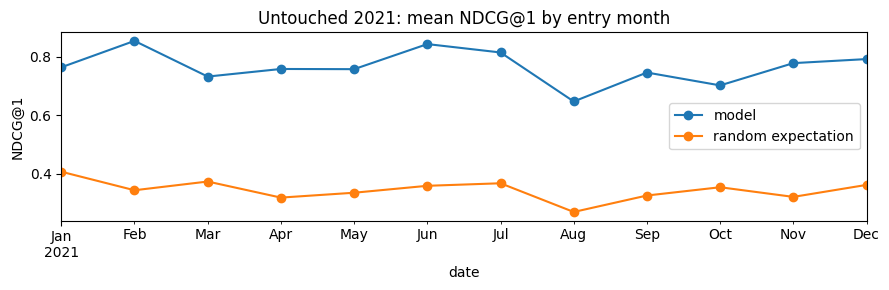

In [13]:
test_metrics = daily_ndcg(test_scores, test_grades)
gains = GAINS[test_grades.unstack('candidate').to_numpy(dtype=int)]
ideal = np.sort(gains, axis=1)[:, ::-1]
discount = 1 / np.log2(np.arange(gains.shape[1]) + 2)
random_metrics = pd.DataFrame(index=test_metrics.index)
for k in [1, 3]:
    expected_dcg = gains.mean(axis=1) * discount[:k].sum()
    idcg = (ideal[:, :k] * discount[:k]).sum(axis=1)
    random_metrics[f'NDCG@{k}'] = np.divide(expected_dcg, idcg,
        out=np.ones_like(expected_dcg), where=idcg != 0)
evaluation = pd.DataFrame({'frozen model': test_metrics.mean(),
                           'random ordering (expectation)': random_metrics.mean()}).T
display(evaluation)
diagnostics = pd.Series({
    'test queries': len(top),
    'fraction choosing a top-grade candidate':
        top.grade.eq(test_grades.groupby(level='date').max()).mean(),
    'fraction choosing SKIP': top.candidate.eq('SKIP').mean(),
    'mean selected continuous z (not P&L)': top.z.mean(),
})
display(diagnostics)
monthly = pd.DataFrame({'model': test_metrics['NDCG@1'],
                        'random expectation': random_metrics['NDCG@1']}).resample('MS').mean()
monthly.plot(marker='o', figsize=(9, 3), title='Untouched 2021: mean NDCG@1 by entry month')
plt.ylabel('NDCG@1')
plt.tight_layout()
plt.show()

## 12. Compact checks

Check the fit's input contract and time boundaries, the source-defined settings, and a
hand-solvable NDCG example. The checks do not require the fake strategy to be profitable
or the model to beat a chosen performance threshold.

In [14]:
assert features == X.columns.tolist() == model.feature_name()
assert model.num_feature() == X.shape[1]
assert len(study.trials) == TRIALS and all(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)
assert model.params['objective'] == 'lambdarank' and model.params['label_gain'] == GAINS.tolist()
assert model.params['ndcg_eval_at'] == [1, 3] and model.params['lambdarank_truncation_level'] == 5
assert 0 < model.best_iteration <= ROUNDS
for mask, end in [(search_fit, '2020-01-01'), (refit, '2020-04-01'),
                  (validation, '2020-07-01'), (early_stop, '2020-07-01')]:
    assert outcomes.loc[mask, 'label_available'].lt(end).all()
    assert not (mask & test).any()
assert not (refit & early_stop).any() and not (search_fit & validation).any()
assert np.all(~early_stop | validation)
assert groups.eq(len(expected_candidates)).all() and groups.sum() == search_fit.sum()
assert test_metrics.ge(0).all().all() and test_metrics.le(1).all().all()
assert top.gap.ge(0).all()
np.testing.assert_array_equal(grade(pd.Series(cuts), cuts), np.arange(4))

# Wrong top pick: NDCG@1=0; the good candidate at rank 2 is discounted.
toy_index = pd.MultiIndex.from_product([pd.to_datetime(['2020-01-01', '2020-01-02']),
                                       ['A', 'B']], names=['date', 'candidate'])
toy_metrics = daily_ndcg(pd.Series([2., 1., 2., 1.], index=toy_index),
                         pd.Series([0, 4, 0, 0], index=toy_index))
np.testing.assert_allclose(toy_metrics.iloc[0], [0., 1 / np.log2(3)])
np.testing.assert_allclose(toy_metrics.iloc[1], [1., 1.])  # All-zero gains.
print('PASS: all features retained, 50 trials, model settings, causal splits, and NDCG calculations.')

PASS: all features retained, 50 trials, model settings, causal splits, and NDCG calculations.


The model artifact consists of **`model`, `features`, and `refit_cuts`**. Features must retain
their names, ordering, units, and availability conventions when scored later. Cutpoints
are needed to grade later outcomes for evaluation; prediction itself only needs the model
and feature matrix.

The main objects to inspect are `split_table`, `cuts`, `worked`, `learning_curve`, `trials`,
`study.best_params`, `refit_cuts`, `rankings`, and `evaluation`.

For the preceding stage, see the [S1–S5 walkthrough](harvesting_vrp_feature_selection.ipynb).
For the subsequent gate, sizing, and portfolio accounting, continue with the
[one-cycle notebook](harvesting_vrp_trend_walkthrough.ipynb). These synthetic ranking
results illustrate fitting mechanics; they are not evidence of a trading edge.